Imports + Setup

In [8]:
import pandas as pd
import os
import glob
import matplotlib

pd.set_option('display.max_columns', None)

Safe Data Loading

In [9]:
# Assuming this notebook is inside a 'notebooks/' folder
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
fact_dir = os.path.join(PROJECT_ROOT, 'data', '03_processed', 'fact_game')

# BIG DATA TRAP AVOIDED: Grab only the first parquet part file
parquet_files = glob.glob(os.path.join(fact_dir, "*.parquet"))

if not parquet_files:
    print(f"Error: No parquet files found in {fact_dir}.")
else:
    sample_file = parquet_files[1]
    print(f"Reading sample: {os.path.basename(sample_file)}")
    df_fact = pd.read_parquet(sample_file)
    print("Data loaded successfully!")

Reading sample: part-00003-1f437c14-0099-4497-9ee1-107737f938d8-c000.snappy.parquet
Data loaded successfully!


Categorical & Null Analysis

In [10]:
# Converting to a dataframe makes the value counts render nicely in Jupyter
category_counts = df_fact['game_category'].value_counts(dropna=False).reset_index()
category_counts.columns = ['game_category', 'count']

category_counts

,game_category,count
0,Blitz,134908
1,Bullet,84593
2,Rapid,33935
3,Classical,1968
4,Untimed,1160


Schema Validation
(To ensure that IDs are ready for the BIGINT MySQL insertion)

In [11]:
pd.DataFrame(df_fact.dtypes, columns=['Data Type'])

,Data Type
game_id,int64
white_player_id,int64
black_player_id,int64
opening_id,int64
white_elo,int64
black_elo,int64
elo_diff,int64
result,str
game_category,str
total_moves,int64


Deep Dive into a Sample Row

In [12]:
#Transposing still works great in notebooks for inspecting wide tables
df_fact.head(4).T

,0,1,2,3
game_id,169380,52897,1097296,1288819
white_player_id,8254569043057869862,5159647679038298372,596126746458558295,4858122668635241744
black_player_id,6448729118331817249,585113641630481561,1825688702830423707,6884151498057883121
opening_id,7185173302053949499,7185173302053949499,1498647308702573485,1498647308702573485
white_elo,1849,1312,1286,1377
black_elo,2148,1235,2242,1801
elo_diff,-299,77,-956,-424
result,0-1,0-1,0-1,0-1
game_category,Bullet,Blitz,Blitz,Bullet
total_moves,70,32,64,6


Quick visual check of your engineered feature

<Axes: title={'center': 'Distribution of Elo Differences'}, ylabel='Frequency'>

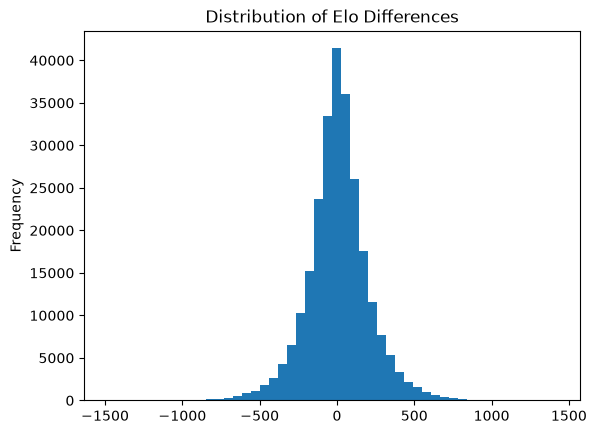

In [13]:
df_fact['elo_diff'].plot(kind='hist', bins=50, title="Distribution of Elo Differences")

Issue checking

In [14]:
#Import os and pandas for this
def check_opening_duplicates():
    # 1. Load the dim_opening parquet files
    base = os.path.abspath(os.path.join(os.getcwd(), '..'))
    opening_path = os.path.join(base, 'data', '03_processed', 'dim_opening')
    
    try:
        df_opening = pd.read_parquet(opening_path)
    except Exception as e:
        print(f"Error loading files: {e}")
        return

    # 2. Find any rows where the opening_id is identical
    duplicates = df_opening[df_opening.duplicated(subset=['opening_id'], keep=False)]
    
    # 3. Output the results
    print(f"Total rows in dim_opening: {len(df_opening)}")
    print(f"Total duplicate IDs found: {len(duplicates)}")
    
    if len(duplicates) > 0:
        print("\n--- SAMPLE OF DUPLICATES ---")
        # Sort by ID so we can see the colliding rows right next to each other
        print(duplicates.sort_values('opening_id').head(10))
    else:
        print("\nNo duplicates found. The issue is resolved/ lies elsewhere.")

check_opening_duplicates()

Total rows in dim_opening: 2929
Total duplicate IDs found: 0

No duplicates found. The issue is resolved/ lies elsewhere.


In [15]:
import os
import glob
import pandas as pd

# 1. Locate the analytics directory
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
analytics_dir = os.path.join(base_dir, 'data', '04_analytics')

# 2. Find the most recently created features folder
feature_folders = glob.glob(os.path.join(analytics_dir, "features_*"))
latest_folder = max(feature_folders, key=os.path.getctime)

# 3. Load a single Parquet file to inspect the structure
sample_file = glob.glob(os.path.join(latest_folder, "*.parquet"))[0]
df_ml = pd.read_parquet(sample_file)

# 4. Print the exact context needed for the LLM prompt
print("--- SCHEMA FOR PROMPT ---")
print(df_ml.dtypes)
print("\n--- SAMPLE ROW FOR PROMPT ---")
print(df_ml.head(1).T)

--- SCHEMA FOR PROMPT ---
game_id            int64
event                str
white                str
black                str
white_elo          int64
black_elo          int64
result               str
time_control         str
opening              str
eco                  str
elo_diff           int64
base_time        float64
increment        float64
game_category        str
total_moves      float64
dtype: object

--- SAMPLE ROW FOR PROMPT ---
                                  0
game_id                         121
event          Rated Classical game
white                       ALEXUSA
black                        gunsti
white_elo                      1589
black_elo                      1670
result                          0-1
time_control                 360+10
opening         Nimzowitsch Defense
eco                             B00
elo_diff                        -81
base_time                     360.0
increment                      10.0
game_category                 Blitz
total_moves   